# 08 — Standard Deep Sequence Models Across All Main Solar Forecasting Tasks

Notebook này chạy riêng các backbone deep sequence ở cấu hình **standard/fuller** hơn so với các bản lite/mini trước đó:

- `TSMixer-standard`
- `PatchTST-standard`
- `iTransformer-standard`

Các task được kiểm tra:

1. `target_1h` trên dữ liệu 3 năm 2016–2018.
2. `target_24h` trên dữ liệu 3 năm 2016–2018.
3. `target_1h` trên dữ liệu 20 năm 2004–2023.
4. `target_24h` trên dữ liệu 20 năm 2004–2023.
5. `next-day daily_total` trên dữ liệu 20 năm.
6. `multi-horizon 24h` trên dữ liệu 20 năm.

Notebook này là thí nghiệm bổ sung để kiểm tra vai trò của model capacity và dữ liệu dài hơn. Nó không thay thế các benchmark tabular/boosting ở notebook 02, 05, 06, 07.

In [1]:
# =========================
# 1. Imports and configuration
# =========================

import os
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ROOT = Path(".")
OUT_DIR = ROOT / "outputs_08"
FIG_DIR = ROOT / "figures_08"
MODEL_DIR = ROOT / "models_08"
for p in [OUT_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

MOROCCO_3Y_PATH = ROOT / "morocco_data.csv"
PROCESSED_3Y_PATH = ROOT / "outputs" / "processed_morocco_hourly_features.csv"

DATA_05_DIR = ROOT / "data_05"
POWER_20Y_FILES = [
    DATA_05_DIR / "nasa_power_errachidia_hourly_2004_2008_LST.csv",
    DATA_05_DIR / "nasa_power_errachidia_hourly_2009_2013_LST.csv",
    DATA_05_DIR / "nasa_power_errachidia_hourly_2014_2018_LST.csv",
    DATA_05_DIR / "nasa_power_errachidia_hourly_2019_2023_LST.csv",
]

LATITUDE = 31.93
LONGITUDE = -4.42

RUN_TASKS = {
    "point_3y": True,
    "point_20y": True,
    "daily_total_20y": True,
    "multihorizon_20y": True,
}

MODELS_TO_RUN = ["TSMixer-standard", "PatchTST-standard", "iTransformer-standard"]

# Set True to test the full notebook flow quickly.
QUICK_TEST = False

LOOKBACK_HOURLY = 168
LOOKBACK_DAILY = 60
HORIZON_MULTI = 24

POINT_3Y_STRIDE = 1
POINT_20Y_STRIDE = 6
MULTIHORIZON_STRIDE = 6
DAILY_STRIDE = 1

MAX_EPOCHS = 25 if not QUICK_TEST else 3
PATIENCE = 5 if not QUICK_TEST else 2
BATCH_SIZE = 128
LEARNING_RATE = 7e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
DAYLIGHT_THRESHOLD = 1.0

print("MAX_EPOCHS:", MAX_EPOCHS)
print("PATIENCE:", PATIENCE)
print("BATCH_SIZE:", BATCH_SIZE)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
MAX_EPOCHS: 25
PATIENCE: 5
BATCH_SIZE: 128


## 2. Data loading and preprocessing

Notebook ưu tiên đọc file processed của notebook 01 nếu có. Nếu chưa có, notebook sẽ đọc trực tiếp `morocco_data.csv`. Dữ liệu 20 năm được đọc từ 4 file NASA POWER trong thư mục `data_05/`.

In [2]:
# =========================
# 2. Data utilities
# =========================

def read_power_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("YEAR"):
            header_idx = i
            break

    if header_idx is None:
        return pd.read_csv(path)
    return pd.read_csv(path, skiprows=header_idx)


def normalize_power_columns(df):
    rename_map = {
        "ALLSKY_SFC_SW_DWN": "Solar_Radiation_Wh_m2",
        "T2M": "Temperature",
        "RH2M": "Humidity",
        "PS": "Pressure",
        "WS10M": "Wind_Speed",
        "WD10M": "Wind_Direction",
    }
    return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}).copy()


def build_datetime_index(df):
    if all(c in df.columns for c in ["YEAR", "MO", "DY", "HR"]):
        tmp = df.copy()
        tmp["datetime"] = pd.to_datetime(
            dict(
                year=tmp["YEAR"].astype(int),
                month=tmp["MO"].astype(int),
                day=tmp["DY"].astype(int),
            )
        ) + pd.to_timedelta(tmp["HR"].astype(int), unit="h")
        tmp = tmp.set_index("datetime").sort_index()
        return tmp[~tmp.index.duplicated(keep="first")]

    if "datetime" in df.columns:
        tmp = df.copy()
        tmp["datetime"] = pd.to_datetime(tmp["datetime"])
        return tmp.set_index("datetime").sort_index()

    if "DATE" in df.columns:
        tmp = df.copy()
        tmp["datetime"] = pd.to_datetime(tmp["DATE"])
        return tmp.set_index("datetime").sort_index()

    raise ValueError("Cannot build datetime index. YEAR/MO/DY/HR or datetime column is required.")


def add_solar_time_features(df, latitude=LATITUDE):
    out = df.copy()
    hour = out.index.hour.values + 0.5
    doy = out.index.dayofyear.values
    month = out.index.month.values

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)

    lat_rad = np.deg2rad(latitude)
    decl = np.deg2rad(23.44) * np.sin(2 * np.pi * (doy - 81) / 365.25)
    hour_angle = np.deg2rad(15 * (hour - 12))
    sin_elev = np.sin(lat_rad) * np.sin(decl) + np.cos(lat_rad) * np.cos(decl) * np.cos(hour_angle)
    sin_elev = np.clip(sin_elev, -1, 1)
    elev_deg = np.rad2deg(np.arcsin(sin_elev))

    out["solar_elevation_proxy_deg"] = elev_deg
    out["sun_up_proxy"] = (elev_deg > 0).astype(float)
    clear_sky = np.maximum(0, sin_elev) * 1000.0
    out["clear_sky_proxy_Wh_m2"] = clear_sky

    if "Solar_Radiation_Wh_m2" in out.columns:
        out["clear_sky_index_current"] = np.clip(
            out["Solar_Radiation_Wh_m2"].values / np.maximum(clear_sky, 1.0),
            0,
            2.0,
        )
    return out


def preprocess_hourly_power(df):
    df = normalize_power_columns(df)
    df = build_datetime_index(df)
    df = df.replace(-999, np.nan).replace([np.inf, -np.inf], np.nan)

    numeric_cols = [
        c for c in [
            "Solar_Radiation_Wh_m2",
            "Temperature",
            "Humidity",
            "Pressure",
            "Wind_Speed",
            "Wind_Direction",
        ]
        if c in df.columns
    ]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df[numeric_cols] = df[numeric_cols].interpolate(limit_direction="both").ffill().bfill()

    if "Solar_Radiation_Wh_m2" not in df.columns:
        raise ValueError("Solar_Radiation_Wh_m2 column is required.")

    df["Solar_Radiation_Wh_m2"] = df["Solar_Radiation_Wh_m2"].clip(lower=0)
    df["Solar_Energy_kJ_m2"] = df["Solar_Radiation_Wh_m2"] * 3.6

    if "Wind_Direction" in df.columns:
        wd_rad = np.deg2rad(df["Wind_Direction"].fillna(0).values)
        df["wind_dir_sin"] = np.sin(wd_rad)
        df["wind_dir_cos"] = np.cos(wd_rad)

    df = add_solar_time_features(df)
    keep_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    df = df[keep_cols].replace([np.inf, -np.inf], np.nan).interpolate(limit_direction="both").ffill().bfill()
    return df


def load_hourly_3y():
    if PROCESSED_3Y_PATH.exists():
        print("Loading processed 3-year data:", PROCESSED_3Y_PATH)
        df = pd.read_csv(PROCESSED_3Y_PATH, index_col=0, parse_dates=True).sort_index()
        if "Solar_Energy_kJ_m2" not in df.columns:
            if "Solar_Radiation_Wh_m2" in df.columns:
                df["Solar_Energy_kJ_m2"] = df["Solar_Radiation_Wh_m2"] * 3.6
            else:
                raise ValueError("Processed data must contain Solar_Energy_kJ_m2 or Solar_Radiation_Wh_m2.")
        df = add_solar_time_features(df)
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        return df[numeric_cols].replace([np.inf, -np.inf], np.nan).interpolate(limit_direction="both").ffill().bfill()

    print("Loading raw 3-year data:", MOROCCO_3Y_PATH)
    raw = read_power_csv(MOROCCO_3Y_PATH)
    return preprocess_hourly_power(raw)


def load_hourly_20y():
    missing = [p for p in POWER_20Y_FILES if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing 20-year NASA POWER files:\n" + "\n".join(map(str, missing)))

    parts = []
    for p in POWER_20Y_FILES:
        part = read_power_csv(p)
        parts.append(part)
        print(p.name, part.shape)

    raw = pd.concat(parts, ignore_index=True)
    return preprocess_hourly_power(raw)

In [3]:
# =========================
# 3. Load datasets
# =========================

hourly_3y = load_hourly_3y()
print("hourly_3y:", hourly_3y.shape, hourly_3y.index.min(), "→", hourly_3y.index.max())

hourly_20y = load_hourly_20y()
print("hourly_20y:", hourly_20y.shape, hourly_20y.index.min(), "→", hourly_20y.index.max())

Loading processed 3-year data: outputs\processed_morocco_hourly_features.csv
hourly_3y: (25944, 80) 2016-01-15 00:00:00 → 2018-12-30 23:00:00
nasa_power_errachidia_hourly_2004_2008_LST.csv (43848, 10)
nasa_power_errachidia_hourly_2009_2013_LST.csv (43824, 10)
nasa_power_errachidia_hourly_2014_2018_LST.csv (43824, 10)
nasa_power_errachidia_hourly_2019_2023_LST.csv (43824, 10)
hourly_20y: (175320, 23) 2004-01-01 00:00:00 → 2023-12-31 23:00:00


## 3. Supervised sequence datasets

Mọi mô hình trong notebook 08 đều dùng input sequence. Dữ liệu được split theo **target time** hoặc **target end time** để tránh việc cửa sổ dự báo vượt qua ranh giới train/validation/test.

In [4]:
# =========================
# 4. Supervised sequence builders
# =========================

def unique_keep_order(items):
    """Remove duplicates while preserving order."""
    return list(dict.fromkeys(items))


def get_hourly_sequence_features(df):
    preferred = [
        "Solar_Energy_kJ_m2",
        "Solar_Radiation_Wh_m2",
        "Temperature",
        "Humidity",
        "Pressure",
        "Wind_Speed",
        "wind_dir_sin",
        "wind_dir_cos",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "month_sin",
        "month_cos",
        "solar_elevation_proxy_deg",
        "sun_up_proxy",
        "clear_sky_proxy_Wh_m2",
        "clear_sky_index_current",
    ]

    return unique_keep_order([
        c for c in preferred
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ])


def split_by_target_time(X, Y, target_times, train_end, val_end):
    target_times = pd.DatetimeIndex(target_times)

    train_mask = target_times <= pd.Timestamp(train_end)
    val_mask = (target_times > pd.Timestamp(train_end)) & (target_times <= pd.Timestamp(val_end))
    test_mask = target_times > pd.Timestamp(val_end)

    return (
        X[train_mask], Y[train_mask], target_times[train_mask],
        X[val_mask], Y[val_mask], target_times[val_mask],
        X[test_mask], Y[test_mask], target_times[test_mask],
    )


def prepare_supervised_frame(df, feature_cols, target_col):
    """
    Build a clean dataframe for sequence modeling.

    The target column is allowed to appear in feature_cols because past target
    values are useful sequence inputs. However, the dataframe must contain each
    column only once; otherwise pandas may return a DataFrame instead of a Series
    when selecting the target, creating an accidental 3D Y array.
    """
    feature_cols = unique_keep_order([
        c for c in feature_cols
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ])

    if target_col not in df.columns:
        raise ValueError(f"Missing target column: {target_col}")

    cols = unique_keep_order(feature_cols + [target_col])

    data = (
        df.loc[:, cols]
        .copy()
        .loc[:, lambda x: ~x.columns.duplicated()]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    X_values = data.loc[:, feature_cols].to_numpy(dtype=np.float32)
    y_values = pd.to_numeric(data[target_col], errors="coerce").to_numpy(dtype=np.float32)

    if y_values.ndim != 1:
        y_values = np.asarray(y_values).reshape(-1)

    return data, X_values, y_values, feature_cols


def make_point_dataset(df, horizon_hours, lookback=168, stride=1, feature_cols=None):
    if feature_cols is None:
        feature_cols = get_hourly_sequence_features(df)

    data, values, target, feature_cols = prepare_supervised_frame(
        df, feature_cols, target_col="Solar_Energy_kJ_m2"
    )
    times = data.index

    X, Y, target_times = [], [], []
    max_anchor = len(data) - horizon_hours - 1

    for anchor in range(lookback - 1, max_anchor + 1, stride):
        X.append(values[anchor - lookback + 1: anchor + 1])
        Y.append([float(target[anchor + horizon_hours])])
        target_times.append(times[anchor + horizon_hours])

    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32).reshape(-1, 1)

    return X, Y, pd.DatetimeIndex(target_times), feature_cols


def make_multihorizon_dataset(df, lookback=168, horizon=24, stride=6, feature_cols=None):
    if feature_cols is None:
        feature_cols = get_hourly_sequence_features(df)

    data, values, target, feature_cols = prepare_supervised_frame(
        df, feature_cols, target_col="Solar_Energy_kJ_m2"
    )
    times = data.index

    X, Y, target_end_times = [], [], []
    max_anchor = len(data) - horizon - 1

    for anchor in range(lookback - 1, max_anchor + 1, stride):
        X.append(values[anchor - lookback + 1: anchor + 1])
        Y.append(target[anchor + 1: anchor + horizon + 1].astype(np.float32))
        target_end_times.append(times[anchor + horizon])

    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)

    if Y.ndim != 2:
        Y = Y.reshape(len(Y), -1)

    return X, Y, pd.DatetimeIndex(target_end_times), feature_cols


def build_daily_frame(hourly_df):
    daily = pd.DataFrame(
        index=pd.date_range(
            hourly_df.index.min().normalize(),
            hourly_df.index.max().normalize(),
            freq="D"
        )
    )

    daily["daily_total_kJ_m2"] = hourly_df["Solar_Energy_kJ_m2"].resample("D").sum()
    daily["daily_radiation_Wh_m2"] = hourly_df["Solar_Radiation_Wh_m2"].resample("D").sum()

    for src, dst in [
        ("Temperature", "temp_mean"),
        ("Humidity", "humidity_mean"),
        ("Pressure", "pressure_mean"),
        ("Wind_Speed", "wind_speed_mean"),
        ("clear_sky_proxy_Wh_m2", "clear_sky_daily_proxy"),
        ("clear_sky_index_current", "clear_sky_index_daily"),
    ]:
        if src in hourly_df.columns:
            if "clear_sky_proxy" in src:
                daily[dst] = hourly_df[src].resample("D").sum()
            else:
                daily[dst] = hourly_df[src].resample("D").mean()

    day = daily.index.dayofyear.values
    month = daily.index.month.values

    daily["doy_sin"] = np.sin(2 * np.pi * day / 365.25)
    daily["doy_cos"] = np.cos(2 * np.pi * day / 365.25)
    daily["month_sin"] = np.sin(2 * np.pi * month / 12)
    daily["month_cos"] = np.cos(2 * np.pi * month / 12)

    lat_rad = np.deg2rad(LATITUDE)
    decl = np.deg2rad(23.44) * np.sin(2 * np.pi * (day - 81) / 365.25)
    sin_elev_noon = np.sin(lat_rad) * np.sin(decl) + np.cos(lat_rad) * np.cos(decl)
    daily["noon_solar_elevation_proxy_deg"] = np.rad2deg(np.arcsin(np.clip(sin_elev_noon, -1, 1)))

    daily = (
        daily
        .replace([np.inf, -np.inf], np.nan)
        .interpolate(limit_direction="both")
        .ffill()
        .bfill()
    )

    return daily


def get_daily_sequence_features(daily_df):
    preferred = [
        "daily_total_kJ_m2",
        "daily_radiation_Wh_m2",
        "temp_mean",
        "humidity_mean",
        "pressure_mean",
        "wind_speed_mean",
        "clear_sky_daily_proxy",
        "clear_sky_index_daily",
        "doy_sin",
        "doy_cos",
        "month_sin",
        "month_cos",
        "noon_solar_elevation_proxy_deg",
    ]

    return unique_keep_order([
        c for c in preferred
        if c in daily_df.columns and pd.api.types.is_numeric_dtype(daily_df[c])
    ])


def make_daily_total_dataset(daily_df, lookback=60, stride=1, feature_cols=None):
    if feature_cols is None:
        feature_cols = get_daily_sequence_features(daily_df)

    data, values, target, feature_cols = prepare_supervised_frame(
        daily_df, feature_cols, target_col="daily_total_kJ_m2"
    )
    times = data.index

    X, Y, target_times = [], [], []
    max_anchor = len(data) - 2

    for anchor in range(lookback - 1, max_anchor + 1, stride):
        X.append(values[anchor - lookback + 1: anchor + 1])
        Y.append([float(target[anchor + 1])])
        target_times.append(times[anchor + 1])

    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32).reshape(-1, 1)

    return X, Y, pd.DatetimeIndex(target_times), feature_cols

## 4. Standard model definitions

Cấu hình ở đây mạnh hơn các bản lite/mini trước đó, nhưng vẫn giữ kích thước hợp lý để chạy trên RTX 4050 6GB VRAM.

In [5]:
# =========================
# 5. Scaling and PyTorch datasets
# =========================

class SequenceDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


def ensure_2d_y(Y, name="Y"):
    Y = np.asarray(Y, dtype=np.float32)

    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)

    if Y.ndim > 2:
        Y = Y.reshape(Y.shape[0], -1)

    if Y.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape {Y.shape}")

    return Y


def scale_sequence_data(X_train, X_val, X_test, Y_train, Y_val, Y_test):
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = np.asarray(X_train, dtype=np.float32)
    X_val = np.asarray(X_val, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)

    Y_train = ensure_2d_y(Y_train, "Y_train")
    Y_val = ensure_2d_y(Y_val, "Y_val")
    Y_test = ensure_2d_y(Y_test, "Y_test")

    n_features = X_train.shape[2]
    x_scaler.fit(X_train.reshape(-1, n_features))

    def scale_X(X):
        X = np.asarray(X, dtype=np.float32)
        n, s, f = X.shape
        return x_scaler.transform(X.reshape(-1, f)).reshape(n, s, f).astype(np.float32)

    y_scaler.fit(Y_train)

    return (
        scale_X(X_train),
        scale_X(X_val),
        scale_X(X_test),
        y_scaler.transform(Y_train).astype(np.float32),
        y_scaler.transform(Y_val).astype(np.float32),
        y_scaler.transform(Y_test).astype(np.float32),
        x_scaler,
        y_scaler,
    )


def make_loaders(X_train, Y_train, X_val, Y_val, batch_size=BATCH_SIZE):
    return (
        DataLoader(
            SequenceDataset(X_train, Y_train),
            batch_size=batch_size,
            shuffle=True,
            drop_last=False,
        ),
        DataLoader(
            SequenceDataset(X_val, Y_val),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        ),
    )

In [6]:
# =========================
# 6. TSMixer-standard, PatchTST-standard, iTransformer-standard
# =========================

class MixerBlock(nn.Module):
    def __init__(self, seq_len, n_features, hidden_dim=256, dropout=0.15):
        super().__init__()
        self.norm_time = nn.LayerNorm(n_features)
        self.time_mlp = nn.Sequential(nn.Linear(seq_len, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, seq_len), nn.Dropout(dropout))
        self.norm_feat = nn.LayerNorm(n_features)
        self.feature_mlp = nn.Sequential(nn.Linear(n_features, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, n_features), nn.Dropout(dropout))
    def forward(self, x):
        y = self.norm_time(x).transpose(1, 2)
        y = self.time_mlp(y).transpose(1, 2)
        x = x + y
        y = self.feature_mlp(self.norm_feat(x))
        return x + y


class TSMixerStandard(nn.Module):
    def __init__(self, seq_len, n_features, out_dim, hidden_dim=256, num_blocks=6, dropout=0.15):
        super().__init__()
        self.blocks = nn.ModuleList([MixerBlock(seq_len, n_features, hidden_dim, dropout) for _ in range(num_blocks)])
        self.norm = nn.LayerNorm(n_features)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(seq_len * n_features, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, out_dim))
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x))


class PatchTSTStandard(nn.Module):
    def __init__(self, seq_len, n_features, out_dim, d_model=128, n_heads=8, num_layers=3, patch_len=None, dropout=0.15):
        super().__init__()
        patch_len = patch_len or (24 if seq_len >= 96 else 7)
        stride = max(1, patch_len // 2)
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = 1 + max(0, (seq_len - patch_len) // stride)
        self.proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model, dropout=dropout, batch_first=True, activation="gelu", norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Flatten(), nn.Linear(self.num_patches * d_model, 2*d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(2*d_model, out_dim))
    def forward(self, x):
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)
        patches = patches.permute(0, 1, 3, 2).contiguous().view(patches.size(0), patches.size(1), -1)
        z = self.proj(patches) + self.pos_embed[:, :patches.size(1), :]
        return self.head(self.encoder(z))


class iTransformerStandard(nn.Module):
    def __init__(self, seq_len, n_features, out_dim, d_model=128, n_heads=8, num_layers=3, dropout=0.15):
        super().__init__()
        self.value_embedding = nn.Linear(seq_len, d_model)
        self.var_embedding = nn.Parameter(torch.zeros(1, n_features, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model, dropout=dropout, batch_first=True, activation="gelu", norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Flatten(), nn.Linear(n_features*d_model, 2*d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(2*d_model, out_dim))
    def forward(self, x):
        z = self.value_embedding(x.transpose(1, 2))
        z = z + self.var_embedding[:, :z.size(1), :]
        return self.head(self.encoder(z))


def build_model(model_name, seq_len, n_features, out_dim):
    if model_name == "TSMixer-standard":
        return TSMixerStandard(seq_len, n_features, out_dim)
    if model_name == "PatchTST-standard":
        return PatchTSTStandard(seq_len, n_features, out_dim)
    if model_name == "iTransformer-standard":
        return iTransformerStandard(seq_len, n_features, out_dim)
    raise ValueError(f"Unknown model: {model_name}")

In [7]:
# =========================
# 7. Training and evaluation
# =========================

def train_one_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    best_state, best_val, wait = None, np.inf, 0
    history = []
    start = time.time()
    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            if GRAD_CLIP is not None:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_losses.append(loss.item())
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())
        tr, va = float(np.mean(train_losses)), float(np.mean(val_losses))
        scheduler.step(va)
        history.append({"epoch": epoch, "train_loss": tr, "val_loss": va, "lr": optimizer.param_groups[0]["lr"]})
        print(f"Epoch {epoch:03d} | train_loss={tr:.6f} | val_loss={va:.6f}")
        if va < best_val - 1e-6:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}. Best val_loss={best_val:.6f}")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), time.time() - start


def predict_model(model, X, y_scaler, batch_size=BATCH_SIZE):
    model.eval()
    dummy_y = np.zeros((len(X), len(y_scaler.mean_)), dtype=np.float32)
    loader = DataLoader(SequenceDataset(X, dummy_y), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).detach().cpu().numpy())
    return np.clip(y_scaler.inverse_transform(np.vstack(preds)), 0, None)


def evaluate_forecast(Y_true, Y_pred, daylight_threshold=DAYLIGHT_THRESHOLD):
    Y_true = np.asarray(Y_true, dtype=np.float32)
    Y_pred = np.asarray(Y_pred, dtype=np.float32)
    if Y_true.ndim == 1: Y_true = Y_true.reshape(-1, 1)
    if Y_pred.ndim == 1: Y_pred = Y_pred.reshape(-1, 1)
    n = min(len(Y_true), len(Y_pred))
    Y_true, Y_pred = Y_true[-n:], Y_pred[-n:]
    yt, yp = Y_true.reshape(-1), Y_pred.reshape(-1)
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    out = {
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(yt, yp)),
        "R2": float(r2_score(yt, yp)),
        "MaxError": float(max_error(yt, yp)),
        "NRMSE": float(rmse / (yt.max() - yt.min())) if (yt.max() - yt.min()) != 0 else np.nan,
    }
    mask = yt > daylight_threshold
    if mask.sum() > 5:
        out["daylight_RMSE"] = float(np.sqrt(mean_squared_error(yt[mask], yp[mask])))
        out["daylight_MAE"] = float(mean_absolute_error(yt[mask], yp[mask]))
        out["daylight_R2"] = float(r2_score(yt[mask], yp[mask]))
    else:
        out["daylight_RMSE"] = np.nan
        out["daylight_MAE"] = np.nan
        out["daylight_R2"] = np.nan
    if Y_true.shape[1] >= 1:
        out["h1_RMSE"] = float(np.sqrt(mean_squared_error(Y_true[:, 0], Y_pred[:, 0])))
    if Y_true.shape[1] >= 12:
        out["h12_RMSE"] = float(np.sqrt(mean_squared_error(Y_true[:, 11], Y_pred[:, 11])))
    if Y_true.shape[1] >= 24:
        out["h24_RMSE"] = float(np.sqrt(mean_squared_error(Y_true[:, 23], Y_pred[:, 23])))
    if Y_true.shape[1] > 1:
        true_total, pred_total = Y_true.sum(axis=1), Y_pred.sum(axis=1)
        out["daily_total_RMSE"] = float(np.sqrt(mean_squared_error(true_total, pred_total)))
        out["daily_total_MAE"] = float(mean_absolute_error(true_total, pred_total))
        out["daily_total_R2"] = float(r2_score(true_total, pred_total))
    return out


def print_metrics(prefix, metrics):
    msg = f"{prefix:<35} | RMSE={metrics.get('RMSE', np.nan):9.3f} | daylight_RMSE={metrics.get('daylight_RMSE', np.nan):9.3f}"
    for k, label in [("h1_RMSE", "h1"), ("h12_RMSE", "h12"), ("h24_RMSE", "h24"), ("daily_total_RMSE", "daily_total_RMSE")]:
        if k in metrics:
            msg += f" | {label}={metrics.get(k, np.nan):9.3f}"
    print(msg)

In [8]:
# =========================
# 8. Experiment runner
# =========================

all_results = []
all_histories = []

def run_deep_experiment(task_name, X, Y, target_times, train_end, val_end, feature_cols, output_dim_note=""):
    print("\n" + "=" * 110)
    print(f"Task: {task_name}")
    print("=" * 110)

    Y = ensure_2d_y(Y, "Y")
    X_train, Y_train, t_train, X_val, Y_val, t_val, X_test, Y_test, t_test = split_by_target_time(
        X, Y, target_times, train_end, val_end
    )

    Y_train = ensure_2d_y(Y_train, "Y_train")
    Y_val = ensure_2d_y(Y_val, "Y_val")
    Y_test = ensure_2d_y(Y_test, "Y_test")

    print("Train:", X_train.shape, Y_train.shape, t_train.min() if len(t_train) else None, "→", t_train.max() if len(t_train) else None)
    print("Val  :", X_val.shape, Y_val.shape, t_val.min() if len(t_val) else None, "→", t_val.max() if len(t_val) else None)
    print("Test :", X_test.shape, Y_test.shape, t_test.min() if len(t_test) else None, "→", t_test.max() if len(t_test) else None)
    print("Features:", len(feature_cols), feature_cols)
    print("Output dim:", Y_train.shape[1], output_dim_note)

    if min(len(X_train), len(X_val), len(X_test)) == 0:
        print("Skipping task because at least one split is empty.")
        return

    X_train_s, X_val_s, X_test_s, Y_train_s, Y_val_s, Y_test_s, x_scaler, y_scaler = scale_sequence_data(
        X_train, X_val, X_test, Y_train, Y_val, Y_test
    )

    train_loader, val_loader = make_loaders(X_train_s, Y_train_s, X_val_s, Y_val_s)
    seq_len, n_features, out_dim = X_train_s.shape[1], X_train_s.shape[2], Y_train_s.shape[1]

    for model_name in MODELS_TO_RUN:
        print("\n" + "-" * 90)
        print(f"Training {model_name} on {task_name}")
        print("-" * 90)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        model = build_model(model_name, seq_len, n_features, out_dim)
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable parameters: {n_params:,}")

        model, hist_df, elapsed = train_one_model(model, train_loader, val_loader)

        val_pred = predict_model(model, X_val_s, y_scaler)
        test_pred = predict_model(model, X_test_s, y_scaler)

        val_metrics = evaluate_forecast(Y_val, val_pred)
        test_metrics = evaluate_forecast(Y_test, test_pred)

        row = {
            "task": task_name,
            "model": model_name,
            "seq_len": seq_len,
            "n_features": n_features,
            "out_dim": out_dim,
            "n_train": len(X_train),
            "n_val": len(X_val),
            "n_test": len(X_test),
            "n_params": n_params,
            "train_seconds": elapsed,
            **{f"val_{k}": v for k, v in val_metrics.items()},
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
        all_results.append(row)

        hist_df = hist_df.copy()
        hist_df["task"] = task_name
        hist_df["model"] = model_name
        all_histories.append(hist_df)

        print_metrics(f"{model_name} Val", val_metrics)
        print_metrics(f"{model_name} Test", test_metrics)

        ckpt_path = MODEL_DIR / f"08_{task_name}_{model_name}.pt".replace("/", "_")
        torch.save({
            "task": task_name,
            "model_name": model_name,
            "state_dict": model.state_dict(),
            "seq_len": seq_len,
            "n_features": n_features,
            "out_dim": out_dim,
            "feature_cols": feature_cols,
            "n_params": n_params,
        }, ckpt_path)

        pd.DataFrame(all_results).to_csv(OUT_DIR / "08_results_all_models.csv", index=False)

        if all_histories:
            pd.concat(all_histories, ignore_index=True).to_csv(OUT_DIR / "08_training_history.csv", index=False)

## 5. Experiments

Chạy lần lượt các task. Nếu muốn kiểm tra nhanh flow, đặt `QUICK_TEST = True` ở cell cấu hình đầu tiên.

In [9]:
# =========================
# 9. Task A: 3-year target_1h and target_24h
# =========================

if RUN_TASKS["point_3y"]:
    feat_cols_3y = get_hourly_sequence_features(hourly_3y)
    for h in [1, 24]:
        X, Y, target_times, used_cols = make_point_dataset(hourly_3y, horizon_hours=h, lookback=LOOKBACK_HOURLY, stride=POINT_3Y_STRIDE, feature_cols=feat_cols_3y)
        run_deep_experiment(
            task_name=f"point_3y_target_{h}h",
            X=X,
            Y=Y,
            target_times=target_times,
            train_end="2017-12-31 23:00:00",
            val_end="2018-06-30 23:00:00",
            feature_cols=used_cols,
            output_dim_note=f"target_{h}h",
        )


Task: point_3y_target_1h
Train: (17040, 168, 16) (17040, 1) 2016-01-22 00:00:00 → 2017-12-31 23:00:00
Val  : (4344, 168, 16) (4344, 1) 2018-01-01 00:00:00 → 2018-06-30 23:00:00
Test : (4392, 168, 16) (4392, 1) 2018-07-01 00:00:00 → 2018-12-30 23:00:00
Features: 16 ['Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'solar_elevation_proxy_deg', 'sun_up_proxy', 'clear_sky_proxy_Wh_m2', 'clear_sky_index_current']
Output dim: 1 target_1h

------------------------------------------------------------------------------------------
Training TSMixer-standard on point_3y_target_1h
------------------------------------------------------------------------------------------
Trainable parameters: 1,258,481
Epoch 001 | train_loss=0.096760 | val_loss=0.023449
Epoch 002 | train_loss=0.019249 | val_loss=0.012015
Epoch 003 | train_loss=0.014527 | val_loss=0.017390
Epoch 004 | train_los

In [10]:
# =========================
# 10. Task B: 20-year target_1h and target_24h
# =========================

if RUN_TASKS["point_20y"]:
    feat_cols_20y = get_hourly_sequence_features(hourly_20y)
    for h in [1, 24]:
        X, Y, target_times, used_cols = make_point_dataset(hourly_20y, horizon_hours=h, lookback=LOOKBACK_HOURLY, stride=POINT_20Y_STRIDE, feature_cols=feat_cols_20y)
        run_deep_experiment(
            task_name=f"point_20y_target_{h}h",
            X=X,
            Y=Y,
            target_times=target_times,
            train_end="2018-12-31 23:00:00",
            val_end="2020-12-31 23:00:00",
            feature_cols=used_cols,
            output_dim_note=f"target_{h}h with 20-year data",
        )


Task: point_20y_target_1h
Train: (21888, 168, 18) (21888, 1) 2004-01-08 00:00:00 → 2018-12-31 18:00:00
Val  : (2924, 168, 18) (2924, 1) 2019-01-01 00:00:00 → 2020-12-31 18:00:00
Test : (4380, 168, 18) (4380, 1) 2021-01-01 00:00:00 → 2023-12-31 18:00:00
Features: 18 ['Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'wind_dir_sin', 'wind_dir_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'solar_elevation_proxy_deg', 'sun_up_proxy', 'clear_sky_proxy_Wh_m2', 'clear_sky_index_current']
Output dim: 1 target_1h with 20-year data

------------------------------------------------------------------------------------------
Training TSMixer-standard on point_20y_target_1h
------------------------------------------------------------------------------------------
Trainable parameters: 1,350,705
Epoch 001 | train_loss=0.078153 | val_loss=0.008179
Epoch 002 | train_loss=0.017928 | val_loss=0.012777
Epoch 003 | train_los

In [11]:
# =========================
# 11. Task C: 20-year next-day daily total
# =========================

if RUN_TASKS["daily_total_20y"]:
    daily_20y = build_daily_frame(hourly_20y)
    daily_features = get_daily_sequence_features(daily_20y)
    X, Y, target_times, used_cols = make_daily_total_dataset(daily_20y, lookback=LOOKBACK_DAILY, stride=DAILY_STRIDE, feature_cols=daily_features)
    run_deep_experiment(
        task_name="daily_total_20y_next_day",
        X=X,
        Y=Y,
        target_times=target_times,
        train_end="2018-12-31",
        val_end="2020-12-31",
        feature_cols=used_cols,
        output_dim_note="next-day daily_total",
    )


Task: daily_total_20y_next_day
Train: (5419, 60, 13) (5419, 1) 2004-03-01 00:00:00 → 2018-12-31 00:00:00
Val  : (731, 60, 13) (731, 1) 2019-01-01 00:00:00 → 2020-12-31 00:00:00
Test : (1095, 60, 13) (1095, 1) 2021-01-01 00:00:00 → 2023-12-31 00:00:00
Features: 13 ['daily_total_kJ_m2', 'daily_radiation_Wh_m2', 'temp_mean', 'humidity_mean', 'pressure_mean', 'wind_speed_mean', 'clear_sky_daily_proxy', 'clear_sky_index_daily', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'noon_solar_elevation_proxy_deg']
Output dim: 1 next-day daily_total

------------------------------------------------------------------------------------------
Training TSMixer-standard on daily_total_20y_next_day
------------------------------------------------------------------------------------------
Trainable parameters: 428,297
Epoch 001 | train_loss=0.279236 | val_loss=0.221337
Epoch 002 | train_loss=0.200814 | val_loss=0.198571
Epoch 003 | train_loss=0.188518 | val_loss=0.172720
Epoch 004 | train_loss=0.173874 

In [12]:
# =========================
# 12. Task D: 20-year multi-horizon 24h forecasting
# =========================

if RUN_TASKS["multihorizon_20y"]:
    feat_cols_20y = get_hourly_sequence_features(hourly_20y)
    X, Y, target_end_times, used_cols = make_multihorizon_dataset(hourly_20y, lookback=LOOKBACK_HOURLY, horizon=HORIZON_MULTI, stride=MULTIHORIZON_STRIDE, feature_cols=feat_cols_20y)
    run_deep_experiment(
        task_name="multihorizon_20y_24h",
        X=X,
        Y=Y,
        target_times=target_end_times,
        train_end="2018-12-31 23:00:00",
        val_end="2020-12-31 23:00:00",
        feature_cols=used_cols,
        output_dim_note="24-step output",
    )


Task: multihorizon_20y_24h
Train: (21885, 168, 18) (21885, 24) 2004-01-08 23:00:00 → 2018-12-31 23:00:00
Val  : (2924, 168, 18) (2924, 24) 2019-01-01 05:00:00 → 2020-12-31 23:00:00
Test : (4380, 168, 18) (4380, 24) 2021-01-01 05:00:00 → 2023-12-31 23:00:00
Features: 18 ['Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature', 'Humidity', 'Pressure', 'Wind_Speed', 'wind_dir_sin', 'wind_dir_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'solar_elevation_proxy_deg', 'sun_up_proxy', 'clear_sky_proxy_Wh_m2', 'clear_sky_index_current']
Output dim: 24 24-step output

------------------------------------------------------------------------------------------
Training TSMixer-standard on multihorizon_20y_24h
------------------------------------------------------------------------------------------
Trainable parameters: 1,356,616
Epoch 001 | train_loss=0.077166 | val_loss=0.030390
Epoch 002 | train_loss=0.044922 | val_loss=0.025305
Epoch 003 | train_loss=0.041

## 6. Final summary

,task,model,n_params,train_seconds,val_daylight_RMSE,test_daylight_RMSE,test_RMSE,test_R2,test_h1_RMSE,test_h12_RMSE,test_h24_RMSE,test_daily_total_RMSE
14,daily_total_20y_next_day,iTransformer-standard,1031041,2.560020,2499.941699,2863.053964,2863.053964,0.781574,2863.053964,NaN,NaN,NaN
12,daily_total_20y_next_day,TSMixer-standard,428297,3.541672,2609.438733,2866.598333,2866.598333,0.781033,2866.598333,NaN,NaN,NaN
13,daily_total_20y_next_day,PatchTST-standard,1199489,3.073176,2736.808908,3006.264127,3006.264127,0.759176,3006.264127,NaN,NaN,NaN
15,multihorizon_20y_24h,TSMixer-standard,1356616,64.882823,232.454481,255.446660,184.469732,0.974650,95.622268,185.254449,184.866379,2442.466479
16,multihorizon_20y_24h,PatchTST-standard,1084568,40.237667,234.029988,257.802386,185.806666,0.974282,101.085717,179.688739,189.082034,2435.093427
17,multihorizon_20y_24h,iTransformer-standard,1215256,52.836688,240.379038,262.834578,189.601453,0.973220,96.984328,183.084306,190.647642,2493.705977
7,point_20y_target_1h,PatchTST-standard,1078657,44.672325,88.550552,107.439772,79.601875,0.996124,79.601875,NaN,NaN,NaN
6,point_20y_target_1h,TSMixer-standard,1350705,123.017546,89.329747,106.854786,79.254978,0.996158,79.254978,NaN,NaN,NaN
8,point_20y_target_1h,iTransformer-standard,1209345,50.132669,91.072178,106.928304,79.162489,0.996167,79.162489,NaN,NaN,NaN
10,point_20y_target_24h,PatchTST-standard,1078657,16.495756,236.601177,257.927830,189.591862,0.976857,189.591862,NaN,NaN,NaN


Best model by validation daylight_RMSE:


,task,model,n_params,train_seconds,val_daylight_RMSE,test_daylight_RMSE,test_RMSE,test_R2,test_h1_RMSE,test_h12_RMSE,test_h24_RMSE,test_daily_total_RMSE
14,daily_total_20y_next_day,iTransformer-standard,1031041,2.560020,2499.941699,2863.053964,2863.053964,0.781574,2863.053964,NaN,NaN,NaN
15,multihorizon_20y_24h,TSMixer-standard,1356616,64.882823,232.454481,255.446660,184.469732,0.974650,95.622268,185.254449,184.866379,2442.466479
7,point_20y_target_1h,PatchTST-standard,1078657,44.672325,88.550552,107.439772,79.601875,0.996124,79.601875,NaN,NaN,NaN
10,point_20y_target_24h,PatchTST-standard,1078657,16.495756,236.601177,257.927830,189.591862,0.976857,189.591862,NaN,NaN,NaN
2,point_3y_target_1h,iTransformer-standard,1143553,27.165635,111.441312,116.604450,83.004197,0.994147,83.004197,NaN,NaN,NaN
4,point_3y_target_24h,PatchTST-standard,1072513,10.437991,306.752165,334.956037,238.553183,0.951657,238.553183,NaN,NaN,NaN


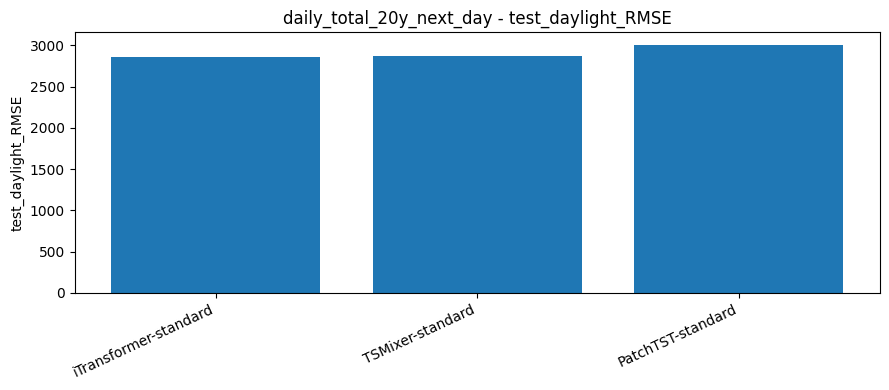

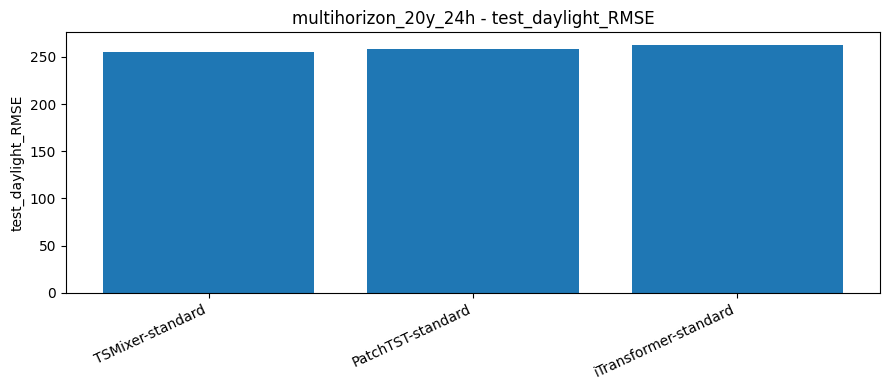

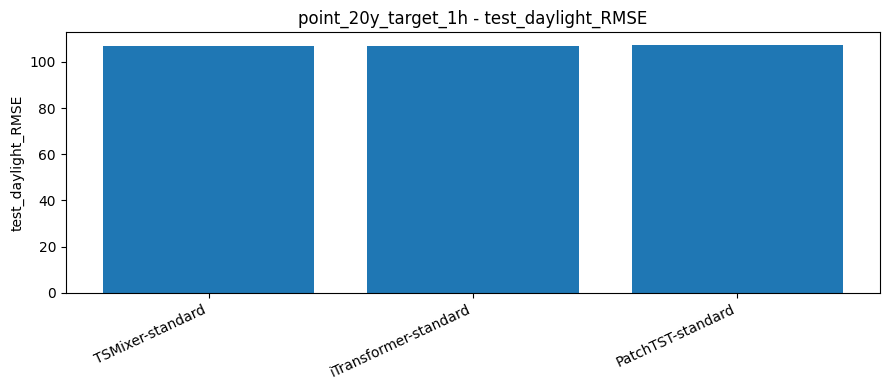

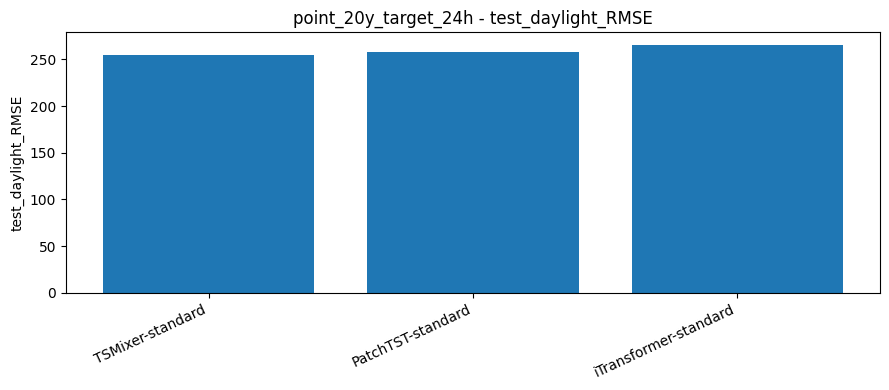

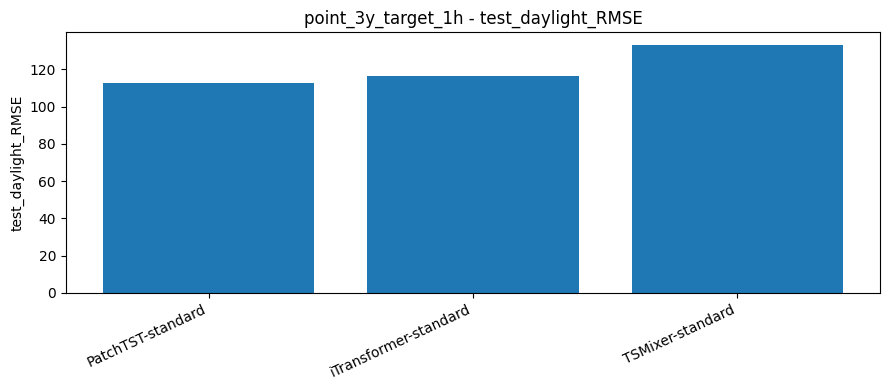

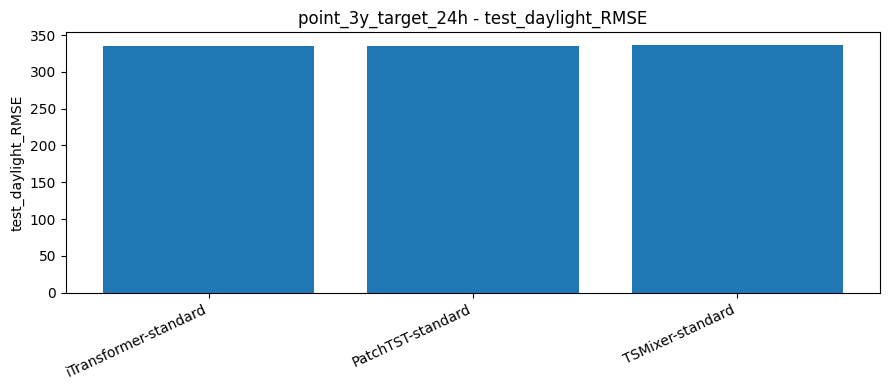

,task,model,test_daylight_RMSE,test_RMSE,test_R2,train_seconds
7,point_20y_target_1h,PatchTST-standard,107.439772,79.601875,0.996124,44.672325
10,point_20y_target_24h,PatchTST-standard,257.927830,189.591862,0.976857,16.495756
1,point_3y_target_1h,PatchTST-standard,112.487443,80.069772,0.994554,26.438032
4,point_3y_target_24h,PatchTST-standard,334.956037,238.553183,0.951657,10.437991
6,point_20y_target_1h,TSMixer-standard,106.854786,79.254978,0.996158,123.017546
9,point_20y_target_24h,TSMixer-standard,254.425540,186.503477,0.977605,73.156399
0,point_3y_target_1h,TSMixer-standard,133.183453,94.937181,0.992343,30.605057
3,point_3y_target_24h,TSMixer-standard,336.790156,239.773045,0.951161,24.243173
8,point_20y_target_1h,iTransformer-standard,106.928304,79.162489,0.996167,50.132669
11,point_20y_target_24h,iTransformer-standard,265.655337,194.708968,0.975591,15.474109


In [13]:
# =========================
# 13. Final summary and plots
# =========================

results_df = pd.DataFrame(all_results)

if results_df.empty:
    print("No results. Check RUN_TASKS and MODELS_TO_RUN.")
else:
    results_df.to_csv(OUT_DIR / "08_results_all_models.csv", index=False)
    display_cols = [
        "task", "model", "n_params", "train_seconds",
        "val_daylight_RMSE", "test_daylight_RMSE",
        "test_RMSE", "test_R2",
        "test_h1_RMSE", "test_h12_RMSE", "test_h24_RMSE",
        "test_daily_total_RMSE",
    ]
    display_cols = [c for c in display_cols if c in results_df.columns]
    summary_df = results_df.sort_values(["task", "val_daylight_RMSE"], na_position="last")
    display(summary_df[display_cols])
    best_by_task = summary_df.groupby("task", as_index=False).head(1)
    best_by_task.to_csv(OUT_DIR / "08_best_by_task.csv", index=False)
    print("Best model by validation daylight_RMSE:")
    display(best_by_task[display_cols])
    if all_histories:
        pd.concat(all_histories, ignore_index=True).to_csv(OUT_DIR / "08_training_history.csv", index=False)
    metric_col = "test_daylight_RMSE" if "test_daylight_RMSE" in results_df.columns else "test_RMSE"
    for task in sorted(results_df["task"].unique()):
        sub = results_df[results_df["task"] == task].sort_values(metric_col)
        plt.figure(figsize=(9, 4))
        plt.bar(sub["model"], sub[metric_col])
        plt.title(f"{task} - {metric_col}")
        plt.ylabel(metric_col)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"08_{task}_{metric_col}.png", dpi=150)
        plt.show()
    point_compare = results_df[results_df["task"].str.contains("point_")]
    if not point_compare.empty:
        compare_cols = ["task", "model", "test_daylight_RMSE", "test_RMSE", "test_R2", "train_seconds"]
        compare_cols = [c for c in compare_cols if c in point_compare.columns]
        point_compare[compare_cols].sort_values(["model", "task"]).to_csv(OUT_DIR / "08_point_3y_vs_20y_comparison.csv", index=False)
        display(point_compare[compare_cols].sort_values(["model", "task"]))

## 7. Notes for report

- Notebook 08 kiểm tra các backbone standard/full hơn, nhưng vẫn cần diễn giải theo trade-off giữa độ chính xác và chi phí tính toán.
- Nếu standard models cải thiện so với lite/mini, có thể kết luận rằng model capacity giúp deep sequence models phát huy tốt hơn.
- Nếu không cải thiện rõ, đây vẫn là kết quả quan trọng: với dữ liệu NASA POWER single-site, các mô hình boosting/ensemble compact ở notebook trước vẫn là baseline rất mạnh.
- Không nên thay thế kết quả chính của notebook 05 và 07 bằng notebook 08 nếu notebook 08 không vượt trội rõ ràng; hãy xem đây là thí nghiệm bổ sung.